## DAVE Demo
- Compare Stable Diffusion3 generation with DAVE!


In [ ]:
import importlib.util
import inspect
import os
import sys
from pathlib import Path

import torch
from matplotlib import gridspec
from matplotlib import pyplot as plt

REPO = Path('You need to fill this path')
DAVE_DIR = REPO / 'DAVE'
DIFFUSERS_SRC = REPO / 'diffusers' / 'src'

sys.path.insert(0, str(DIFFUSERS_SRC))

# Runtime compatibility for the clean DAVE files, without editing source code.
import diffusers.loaders as loaders_pkg
import diffusers.models.attention as attention_pkg
import diffusers.utils as utils_pkg

if not hasattr(loaders_pkg, 'SD3IPAdapterMixin'):
    loaders_pkg.SD3IPAdapterMixin = loaders_pkg.IPAdapterMixin

if not hasattr(loaders_pkg, 'SD3Transformer2DLoadersMixin'):
    class SD3Transformer2DLoadersMixin:
        pass

    loaders_pkg.SD3Transformer2DLoadersMixin = SD3Transformer2DLoadersMixin

if not hasattr(attention_pkg, 'AttentionMixin'):
    class AttentionMixin:
        pass

    attention_pkg.AttentionMixin = AttentionMixin

if 'joint_attention_kwargs' not in inspect.signature(attention_pkg.JointTransformerBlock.forward).parameters:
    _orig_joint_transformer_forward = attention_pkg.JointTransformerBlock.forward

    def _joint_transformer_forward_compat(
        self,
        hidden_states,
        encoder_hidden_states,
        temb,
        joint_attention_kwargs=None,
        *args,
        **kwargs,
    ):
        return _orig_joint_transformer_forward(
            self,
            hidden_states=hidden_states,
            encoder_hidden_states=encoder_hidden_states,
            temb=temb,
            *args,
            **kwargs,
        )

    attention_pkg.JointTransformerBlock.forward = _joint_transformer_forward_compat

if not hasattr(utils_pkg, 'apply_lora_scale'):
    def apply_lora_scale(_arg_name):
        def decorator(func):
            return func

        return decorator

    utils_pkg.apply_lora_scale = apply_lora_scale

def load_module(module_name, path):
    spec = importlib.util.spec_from_file_location(module_name, path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module

# Load DAVE transformer first, then make the diffusers package point to it.
dave_transformer_mod = load_module(
    'diffusers.models.transformers.transformer_sd3',
    DAVE_DIR / 'transformer_sd3.py',
)

import diffusers.models.transformers as transformers_pkg
transformers_pkg.SD3Transformer2DModel = dave_transformer_mod.SD3Transformer2DModel

dave_pipeline_mod = load_module(
    'diffusers.pipelines.stable_diffusion_3.pipeline_stable_diffusion_3',
    DAVE_DIR / 'pipeline_stable_diffusion_3.py',
)
StableDiffusion3Pipeline = dave_pipeline_mod.StableDiffusion3Pipeline

print('Loaded DAVE pipeline:', StableDiffusion3Pipeline)
print('Loaded DAVE transformer:', transformers_pkg.SD3Transformer2DModel)


Loaded DAVE pipeline: <class 'diffusers.pipelines.stable_diffusion_3.pipeline_stable_diffusion_3.StableDiffusion3Pipeline'>
Loaded DAVE transformer: <class 'diffusers.models.transformers.transformer_sd3.SD3Transformer2DModel'>


In [5]:
MODEL_ID = 'stabilityai/stable-diffusion-3-medium-diffusers'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE = torch.float16 if DEVICE == 'cuda' else torch.float32

pipe = StableDiffusion3Pipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
)
pipe = pipe.to(DEVICE)
pipe.set_progress_bar_config(disable=False)

print('Device:', DEVICE)

Loading pipeline components...: 100%|██████████| 9/9 [00:02<00:00,  4.37it/s]


Device: cuda


100%|██████████| 28/28 [00:03<00:00,  9.09it/s]


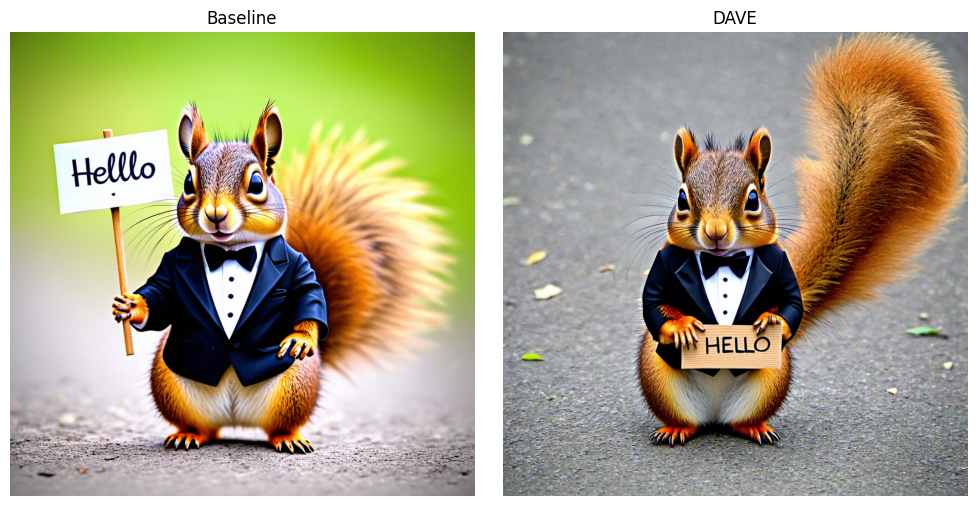

Saved: /home/haeun/Creative_StableDiffusion/DAVE/demo_outputs/baseline.png
Saved: /home/haeun/Creative_StableDiffusion/DAVE/demo_outputs/dave.png


In [8]:
PROMPT = 'A photo of a squirrel in a tuxedo with a sign that says “Hello”'
SEED = 0
NUM_STEPS = 28
GUIDANCE = 7.0

# DAVE_SCALE scales DC, i.e. the feature mean over tokens.
# 1.0 means no change, 0.5 weakens DC, 0.0 removes DC.
DAVE_SCALE = 0.5
DAVE_STEPS = [0, 1, 2, 3]  # Denoising loop step indices, not scheduler timestep values.

def make_generator(seed):
    return torch.Generator(device=DEVICE).manual_seed(seed)

common_kwargs = dict(
    prompt=PROMPT,
    num_inference_steps=NUM_STEPS,
    guidance_scale=GUIDANCE,
)

baseline = pipe(
    **common_kwargs,
    generator=make_generator(SEED),
    use_dave=False,
).images[0]

dave = pipe(
    **common_kwargs,
    generator=make_generator(SEED),
    use_dave=True,
    dave_steps=DAVE_STEPS,
    dave_scale=DAVE_SCALE,
).images[0]

out_dir = DAVE_DIR / 'demo_outputs'
out_dir.mkdir(parents=True, exist_ok=True)
baseline.save(out_dir / 'baseline.png')
dave.save(out_dir / 'dave.png')

gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])
fig = plt.figure(figsize=(10, 5))
ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1])
ax1.imshow(baseline)
ax1.axis('off')
ax1.set_title('Baseline')
ax2.imshow(dave)
ax2.axis('off')
ax2.set_title('DAVE')
plt.tight_layout()
plt.show()
print('Saved:', out_dir / 'baseline.png')
print('Saved:', out_dir / 'dave.png')
